# Flight Delay Analysis and Prediction
**Course:** PAML Spring 2026  
**Team:** Lin Wu, Yufan Peng, Xinrui Song, Xinyi Huang, Zhiying Huo  
**Data Source:** U.S. Bureau of Transportation Statistics (BTS) — 2025 Airline On-Time Performance

---
### Project Overview
This notebook covers the full ML pipeline:
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Airline performance evaluation
4. Random Forest classification (predict delay ≥15 min)
5. Linear regression (predict delay duration)
6. Streamlit deployment code

---
## ⚙️ Configuration — Fill This In Before Running

> **Only one variable needs to be changed before running the entire notebook:**  
> Set `data_directory` to the local folder where your BTS CSV dataset files are stored.  
> All subsequent cells will use this path automatically — no need to change it again.
>
> Download the dataset at: https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGK&QO_fu146_anzr=b0-gvzr

In [20]:
# ============================================================
# TODO: Change this to your local folder containing the CSV files
data_directory = '/Users/linwu/Downloads'
# ============================================================

print(f"Data directory set to: {data_directory}")

Data directory: /Users/linwu/Downloads


---
## Section 1 — Setup

In [21]:
import glob
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    r2_score,
)

# ── Column definitions ────────────────────────────────────────────────────────
REQUIRED_COLUMNS = [
    'YEAR', 'QUARTER', 'MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER',
    'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_NM',
    'DEST',  'DEST_CITY_NAME',   'DEST_STATE_NM',
    'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15',
    'AIR_TIME', 'DISTANCE',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
]

DELAY_COLUMNS = [
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
]

# Features used by both classification and regression models
# Includes route, airline, temporal, and operational delay features
CLASSIFICATION_FEATURES = [
    'MONTH', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST',
    'DISTANCE', 'AIR_TIME',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
]

REGRESSION_FEATURES = CLASSIFICATION_FEATURES.copy()

RANDOM_STATE  = 42
TEST_SIZE     = 0.2
SAMPLE_SIZE   = 200_000

---
## Section 2 — Helper Functions

In [22]:
def load_and_prepare_data(directory):
    """
    Load and combine BTS On-Time Reporting CSV files from a directory.
    Matches files like 202501T_ONTIME_REPORTING.csv; falls back to all CSVs.
    Only reads REQUIRED_COLUMNS to save memory. Validates column presence.
    Raises FileNotFoundError if no matching files are found.
    """
    # Try BTS-specific pattern first; fall back to all CSVs
    csv_files = sorted(glob.glob(f"{directory}/*ONTIME_REPORTING.csv"))
    if not csv_files:
        csv_files = sorted(glob.glob(f"{directory}/*.csv"))
    print(f"Files detected ({len(csv_files)}): {[f.split('/')[-1] for f in csv_files]}")
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {directory}")

    frames = []
    for f in csv_files:
        frame = pd.read_csv(f, usecols=lambda col: col in REQUIRED_COLUMNS)
        frame['source_file'] = f.split('/')[-1]
        frames.append(frame)

    combined_df = pd.concat(frames, ignore_index=True)

    missing = sorted(set(REQUIRED_COLUMNS) - set(combined_df.columns))
    if missing:
        print(f"⚠️  Columns not found in dataset (will be skipped): {missing}")

    print(f"Loaded {len(combined_df):,} rows from {len(csv_files)} file(s).")
    return combined_df

In [23]:
def clean_data(df, delay_columns):
    """
    Drop rows with NaN in key delay columns; clip negatives to 0;
    coerce numeric types; add distance_bucket feature.
    """
    df_cleaned = df.dropna(subset=delay_columns).copy()

    # Clip negative delay values to 0
    for col in ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
                'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'DEP_DELAY_NEW']:
        if col in df_cleaned.columns:
            df_cleaned[col] = df_cleaned[col].clip(lower=0)

    # Coerce numeric types (guards against mixed-type CSVs)
    for col in ['MONTH', 'DISTANCE', 'AIR_TIME', 'DEP_DEL15', 'DEP_DELAY_NEW']:
        if col in df_cleaned.columns:
            df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

    df_cleaned = df_cleaned.dropna(
        subset=[c for c in ['MONTH', 'DISTANCE', 'AIR_TIME', 'DEP_DEL15', 'DEP_DELAY_NEW']
                if c in df_cleaned.columns]
    )

    if 'DEP_DEL15' in df_cleaned.columns:
        df_cleaned['DEP_DEL15'] = df_cleaned['DEP_DEL15'].astype(int)

    # Add distance bucket feature
    if 'DISTANCE' in df_cleaned.columns:
        df_cleaned['distance_bucket'] = pd.cut(
            df_cleaned['DISTANCE'],
            bins=[-1, 500, 1500, float('inf')],
            labels=['short_haul', 'medium_haul', 'long_haul']
        )

    return df_cleaned


def sample_data(df, sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE):
    """Return a random sample of df if it exceeds sample_size rows."""
    if sample_size <= 0 or len(df) <= sample_size:
        return df
    print(f"Sampling {sample_size:,} rows from {len(df):,} total rows.")
    return df.sample(n=sample_size, random_state=random_state)

In [24]:
def build_preprocessor(features):
    """
    Build a ColumnTransformer that:
    - Imputes + scales numeric features
    - Imputes + one-hot-encodes categorical features
    """
    numeric_cols = [f for f in features if f in {
        'MONTH', 'DISTANCE', 'AIR_TIME',
        'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
        'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
    }]
    categorical_cols = [f for f in features if f not in numeric_cols]

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    return ColumnTransformer(transformers=[
        ('num', numeric_pipeline,     numeric_cols),
        ('cat', categorical_pipeline, categorical_cols),
    ])

In [25]:
def overall_delay_analysis(df):
    """Return (avg_incl_neg, avg_excl_neg, early_departure_pct)."""
    avg_incl = df['DEP_DELAY'].mean()
    avg_excl = df['DEP_DELAY_NEW'].mean()
    early_pct = (df['DEP_DELAY'] < 0).sum() / len(df) * 100
    return avg_incl, avg_excl, early_pct


def analyze_grouped_counts(df):
    """
    Count flights by delay group.
    Uses DEP_DELAY_GROUP if available; otherwise bins DEP_DELAY_NEW into groups.
    """
    if 'DEP_DELAY_GROUP' in df.columns:
        return df['DEP_DELAY_GROUP'].value_counts().sort_index()

    # Derive delay group from DEP_DELAY (same BTS definition)
    bins   = [-float('inf'), -1, 0, 15, 30, 45, 60, 119, 179, 239, 299, 359, float('inf')]
    labels = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 12]
    df = df.copy()
    df['DEP_DELAY_GROUP'] = pd.cut(df['DEP_DELAY'], bins=bins, labels=labels).astype(float)
    return df['DEP_DELAY_GROUP'].value_counts().sort_index()


def delay_factor_pie_charts(df, delay_columns):
    """
    Pie charts for overall delay factors and high-severity delays (≥61 min).
    High severity is defined as DEP_DELAY_NEW > 60 when DEP_DELAY_GROUP is absent.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    overall = df[delay_columns].sum()
    axes[0].pie(overall, labels=delay_columns, autopct='%1.1f%%', startangle=140)
    axes[0].set_title('Overall Delay Factors')

    # High-severity: DEP_DELAY_GROUP >= 4 (≥61 min) or DEP_DELAY_NEW > 60
    if 'DEP_DELAY_GROUP' in df.columns:
        high_mask = df['DEP_DELAY_GROUP'] >= 4
    else:
        high_mask = df['DEP_DELAY_NEW'] > 60

    high = df[high_mask][delay_columns].sum()
    axes[1].pie(high, labels=delay_columns, autopct='%1.1f%%', startangle=140)
    axes[1].set_title('High-Severity Delay Factors (>60 min)')

    plt.tight_layout()
    plt.savefig('delay_factor_pie_charts.png', dpi=150)
    plt.show()


def compare_short_long_haul(df, delay_columns):
    """Compare average delay factors for short-haul (≤500 mi) vs long-haul (>1500 mi)."""
    short_avg = df[df['DISTANCE'] <= 500][delay_columns].mean()
    long_avg  = df[df['DISTANCE'] >  1500][delay_columns].mean()
    return short_avg, long_avg


def top_cities_by_delay(df, delay_columns):
    """Return the top origin city (most total delay minutes) per delay reason."""
    top_cities = {}
    for reason in delay_columns:
        by_city = df.groupby('ORIGIN_CITY_NAME')[reason].sum()
        top_cities[reason] = {"City": by_city.idxmax(), "Total Delay (min)": by_city.max()}
    return pd.DataFrame(top_cities).T


def analyze_weather_delay_in_dallas_by_quarter(df):
    """Total WEATHER_DELAY in Dallas/Fort Worth by quarter."""
    if 'QUARTER' not in df.columns:
        print("'QUARTER' column missing.")
        return None
    dallas = df[df['ORIGIN_CITY_NAME'] == "Dallas/Fort Worth, TX"]
    return dallas.groupby('QUARTER')['WEATHER_DELAY'].sum()

In [26]:
def calculate_airline_delay_metrics(df):
    """Aggregate delay metrics per airline carrier."""
    perf = df.groupby('OP_UNIQUE_CARRIER').agg(
        DEP_DEL15        = ('DEP_DEL15',          'mean'),
        CARRIER_DELAY    = ('CARRIER_DELAY',       'sum'),
        WEATHER_DELAY    = ('WEATHER_DELAY',       'sum'),
        NAS_DELAY        = ('NAS_DELAY',           'sum'),
        SECURITY_DELAY   = ('SECURITY_DELAY',      'sum'),
        LATE_AIRCRAFT_DELAY = ('LATE_AIRCRAFT_DELAY', 'sum'),
        DEP_DELAY_NEW    = ('DEP_DELAY_NEW',       'mean'),
    ).reset_index()
    perf['Total_Flights']            = df.groupby('OP_UNIQUE_CARRIER').size().values
    perf['Delay_Ratio (%)']          = perf['DEP_DEL15'] * 100
    perf['Avg_Delay_Per_Flight (min)'] = perf['DEP_DELAY_NEW']
    perf['Total_Delay (min)']        = perf[DELAY_COLUMNS].sum(axis=1)
    perf['Delay_Contribution (%)']   = perf['Total_Delay (min)'] / perf['Total_Delay (min)'].sum() * 100
    return perf


def best_and_worst_airlines(airline_performance):
    """Return top-5 best and top-5 worst airlines by Delay_Ratio (%)."""
    best  = airline_performance.nsmallest(5, 'Delay_Ratio (%)')
    worst = airline_performance.nlargest(5,  'Delay_Ratio (%)')
    return best, worst


def airline_performance_by_factor(best, worst, delay_columns):
    """Extract delay factor columns for best and worst airlines."""
    cols = ['OP_UNIQUE_CARRIER'] + delay_columns
    return best[cols], worst[cols]


def visualize_airline_performance_metrics(airline_performance):
    """Bar plots for delay ratio and average delay; heatmap for delay correlations."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.barplot(ax=axes[0],
                data=airline_performance.sort_values('Delay_Ratio (%)', ascending=False),
                x='OP_UNIQUE_CARRIER', y='Delay_Ratio (%)')
    axes[0].set_title('Delay Ratio (%) by Airline')
    axes[0].set_xlabel('Airline'); axes[0].set_ylabel('Delay Ratio (%)')
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(ax=axes[1],
                data=airline_performance.sort_values('Avg_Delay_Per_Flight (min)', ascending=False),
                x='OP_UNIQUE_CARRIER', y='Avg_Delay_Per_Flight (min)')
    axes[1].set_title('Avg Delay Per Flight (min) by Airline')
    axes[1].set_xlabel('Airline'); axes[1].set_ylabel('Avg Delay (min)')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('airline_delay_bar_charts.png', dpi=150)
    plt.show()

    plt.figure(figsize=(10, 8))
    delay_corr = airline_performance[DELAY_COLUMNS].corr()
    sns.heatmap(delay_corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Between Delay Types')
    plt.tight_layout()
    plt.savefig('correlation_heatmap_delay_types.png', dpi=150)
    plt.show()

In [27]:
def train_and_evaluate_classifier(df, best_airlines, worst_airlines):
    """
    Train Logistic Regression (baseline) and Random Forest (main) classifiers
    using a full feature set with sklearn Pipeline preprocessing.
    Target: DEP_DEL15 (1 = delayed ≥15 min).
    Returns the trained Random Forest pipeline.
    """
    model_df = sample_data(df)

    # Guard: drop rows missing any required feature or target
    needed = CLASSIFICATION_FEATURES + ['DEP_DEL15']
    available = [c for c in needed if c in model_df.columns]
    model_df = model_df[available].dropna(subset=['DEP_DEL15'])

    features_to_use = [c for c in CLASSIFICATION_FEATURES if c in model_df.columns]
    X = model_df[features_to_use]
    y = model_df['DEP_DEL15'].astype(int)

    stratify_arg = y if y.nunique() >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify_arg
    )

    preprocessor = build_preprocessor(features_to_use)

    # ── Baseline: Logistic Regression ─────────────────────────────────────────
    print("\n=== Baseline: Logistic Regression ===")
    lr_pipe = Pipeline([
        ('preprocess', build_preprocessor(features_to_use)),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced',
                                     random_state=RANDOM_STATE)),
    ])
    lr_pipe.fit(X_train, y_train)
    lr_pred = lr_pipe.predict(X_test)
    print(classification_report(y_test, lr_pred, zero_division=0))
    print(f"Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
    print(f"Precision: {precision_score(y_test, lr_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test, lr_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_test, lr_pred, zero_division=0):.4f}")

    # ── Main Model: Random Forest ──────────────────────────────────────────────
    print("\n=== Main Model: Random Forest ===")
    rf_pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=150, max_depth=16, min_samples_leaf=5,
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
    rf_pipe.fit(X_train, y_train)
    rf_pred = rf_pipe.predict(X_test)
    print(classification_report(y_test, rf_pred, zero_division=0))
    print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
    print(f"Precision: {precision_score(y_test, rf_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test, rf_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_test, rf_pred, zero_division=0):.4f}")

    # Confusion matrices side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, pred, title in zip(axes, [lr_pred, rf_pred],
                                ['Logistic Regression', 'Random Forest']):
        ConfusionMatrixDisplay(
            confusion_matrix(y_test, pred), display_labels=['On-Time', 'Delayed']
        ).plot(ax=ax, colorbar=False)
        ax.set_title(f'Confusion Matrix — {title}')
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=150)
    plt.show()

    # Per-airline delay likelihood using the RF pipeline
    print("\nAverage Delay Likelihood by Airline (Random Forest):")
    for label, group in [('Best 5', best_airlines), ('Worst 5', worst_airlines)]:
        print(f"  — {label} airlines —")
        for airline in group['OP_UNIQUE_CARRIER']:
            data = df[df['OP_UNIQUE_CARRIER'] == airline][features_to_use].dropna()
            if not data.empty:
                prob = rf_pipe.predict_proba(data)[:, 1].mean()
                print(f"    {airline}: {prob:.2%}")

    # Save metrics to JSON
    metrics = {
        'logistic_regression': {
            'accuracy':  float(accuracy_score(y_test, lr_pred)),
            'precision': float(precision_score(y_test, lr_pred, zero_division=0)),
            'recall':    float(recall_score(y_test, lr_pred, zero_division=0)),
            'f1':        float(f1_score(y_test, lr_pred, zero_division=0)),
        },
        'random_forest_classifier': {
            'accuracy':  float(accuracy_score(y_test, rf_pred)),
            'precision': float(precision_score(y_test, rf_pred, zero_division=0)),
            'recall':    float(recall_score(y_test, rf_pred, zero_division=0)),
            'f1':        float(f1_score(y_test, rf_pred, zero_division=0)),
        },
    }
    with open('classification_metrics.json', 'w') as fp:
        json.dump(metrics, fp, indent=2)
    print("\nSaved: classification_metrics.json")

    return rf_pipe


def random_forest_regression_analysis(df, target='DEP_DELAY_NEW'):
    """
    Train a Random Forest Regressor to predict departure delay duration.
    Only trains on actually-delayed flights (DEP_DELAY_NEW > 0).
    Uses the same full feature set with Pipeline preprocessing.
    Reports RMSE; saves metrics to JSON.
    Returns the trained pipeline.
    """
    print("\n=== Regression: Random Forest Regressor (delayed flights only) ===")

    features_to_use = [c for c in REGRESSION_FEATURES if c in df.columns]
    reg_df = df[df[target] > 0].copy() if target in df.columns else df.copy()
    reg_df = reg_df[features_to_use + [target]].dropna()

    reg_df = sample_data(reg_df)

    X = reg_df[features_to_use]
    y = reg_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    rf_reg_pipe = Pipeline([
        ('preprocess', build_preprocessor(features_to_use)),
        ('model', RandomForestRegressor(
            n_estimators=150, max_depth=18, min_samples_leaf=5,
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
    rf_reg_pipe.fit(X_train, y_train)
    y_pred = rf_reg_pipe.predict(X_test)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    print(f"RMSE                : {rmse:.2f} minutes")
    print(f"Mean actual delay   : {y_test.mean():.2f} minutes")
    print(f"Mean predicted delay: {y_pred.mean():.2f} minutes")

    # Scatter: actual vs predicted (sample 2000 points for readability)
    idx = np.random.default_rng(RANDOM_STATE).choice(len(y_test), min(2000, len(y_test)), replace=False)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test.iloc[idx], y_pred[idx], alpha=0.4, edgecolor='k', s=20)
    lim = max(y_test.max(), y_pred.max())
    plt.plot([0, lim], [0, lim], 'r--', label='Perfect fit')
    plt.title("Random Forest Regressor — Actual vs Predicted Delay")
    plt.xlabel("Actual Delay (min)")
    plt.ylabel("Predicted Delay (min)")
    plt.legend()
    plt.tight_layout()
    plt.savefig('regression_actual_vs_predicted.png', dpi=150)
    plt.show()

    # Save metrics
    with open('regression_metrics.json', 'w') as fp:
        json.dump({'random_forest_regressor': {
            'rmse': rmse,
            'mean_actual_delay':    float(y_test.mean()),
            'mean_predicted_delay': float(y_pred.mean()),
        }}, fp, indent=2)
    print("Saved: regression_metrics.json")

    return rf_reg_pipe

---
## Section 3 — Load Data

In [28]:
df = load_and_prepare_data(data_directory)

Files detected (8): ['202501T_ONTIME_REPORTING.csv', '202502T_ONTIME_REPORTING.csv', '202503T_ONTIME_REPORTING.csv', '202505T_ONTIME_REPORTING.csv', '202508T_ONTIME_REPORTING.csv', '202509T_ONTIME_REPORTING.csv', '202511T_ONTIME_REPORTING.csv', '202512T_ONTIME_REPORTING.csv']
Loaded 4,568,822 rows from 8 file(s).


---
## Section 4 — Exploratory Data Analysis (EDA)

In [29]:
print("Shape:", df.shape)
print("\nAll columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Shape: (4568822, 22)

All columns:
   1. YEAR
   2. QUARTER
   3. MONTH
   4. FL_DATE
   5. OP_UNIQUE_CARRIER
   6. ORIGIN
   7. ORIGIN_CITY_NAME
   8. ORIGIN_STATE_NM
   9. DEST
  10. DEST_CITY_NAME
  11. DEST_STATE_NM
  12. DEP_DELAY
  13. DEP_DELAY_NEW
  14. DEP_DEL15
  15. AIR_TIME
  16. DISTANCE
  17. CARRIER_DELAY
  18. WEATHER_DELAY
  19. NAS_DELAY
  20. SECURITY_DELAY
  21. LATE_AIRCRAFT_DELAY
  22. source_file


In [30]:
print("\nDataset info:")
df.info()

print("\nMissing values (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4568822 entries, 0 to 4568821
Data columns (total 22 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   QUARTER              int64  
 2   MONTH                int64  
 3   FL_DATE              object 
 4   OP_UNIQUE_CARRIER    object 
 5   ORIGIN               object 
 6   ORIGIN_CITY_NAME     object 
 7   ORIGIN_STATE_NM      object 
 8   DEST                 object 
 9   DEST_CITY_NAME       object 
 10  DEST_STATE_NM        object 
 11  DEP_DELAY            float64
 12  DEP_DELAY_NEW        float64
 13  DEP_DEL15            float64
 14  AIR_TIME             float64
 15  DISTANCE             float64
 16  CARRIER_DELAY        float64
 17  WEATHER_DELAY        float64
 18  NAS_DELAY            float64
 19  SECURITY_DELAY       float64
 20  LATE_AIRCRAFT_DELAY  float64
 21  source_file          object 
dtypes: float64(10), int64(3), object(9)
memory usage: 7

In [31]:
df.head()

,YEAR,QUARTER,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST,DEST_CITY_NAME,...,DEP_DELAY_NEW,DEP_DEL15,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,source_file
0,2025,1,1,1/1/2025 12:00:00 AM,AA,JFK,"New York, NY",New York,LAX,"Los Angeles, CA",...,0.0,0.0,345.0,2475.0,NaN,NaN,NaN,NaN,NaN,202501T_ONTIME_REPORTING.csv
1,2025,1,1,1/1/2025 12:00:00 AM,AA,LAX,"Los Angeles, CA",California,JFK,"New York, NY",...,0.0,0.0,274.0,2475.0,NaN,NaN,NaN,NaN,NaN,202501T_ONTIME_REPORTING.csv
2,2025,1,1,1/1/2025 12:00:00 AM,AA,MSN,"Madison, WI",Wisconsin,CLT,"Charlotte, NC",...,36.0,1.0,91.0,708.0,20.0,0.0,0.0,0.0,0.0,202501T_ONTIME_REPORTING.csv
3,2025,1,1,1/1/2025 12:00:00 AM,AA,PHL,"Philadelphia, PA",Pennsylvania,LAS,"Las Vegas, NV",...,1.0,0.0,306.0,2176.0,NaN,NaN,NaN,NaN,NaN,202501T_ONTIME_REPORTING.csv
4,2025,1,1,1/1/2025 12:00:00 AM,AA,ORD,"Chicago, IL",Illinois,PHX,"Phoenix, AZ",...,0.0,0.0,212.0,1440.0,0.0,0.0,44.0,0.0,0.0,202501T_ONTIME_REPORTING.csv


In [32]:
df.describe()

,YEAR,QUARTER,MONTH,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,4568822.0,4.568822e+06,4.568822e+06,4.501713e+06,4.501713e+06,4.501713e+06,4.487901e+06,4.568822e+06,952366.000000,952366.000000,952366.000000,952366.000000,952366.000000
mean,2025.0,2.399451e+00,6.462288e+00,1.254651e+01,1.614119e+01,2.073024e-01,1.169781e+02,8.434628e+02,23.652880,4.687794,16.015502,0.097812,27.844720
std,0.0,1.210318e+00,3.894814e+00,5.608656e+01,5.489548e+01,4.053741e-01,7.139168e+01,6.011621e+02,74.594086,35.842468,36.286499,3.145071,61.311422
min,2025.0,1.000000e+00,1.000000e+00,-1.150000e+02,0.000000e+00,0.000000e+00,8.000000e+00,3.100000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025.0,1.000000e+00,3.000000e+00,-6.000000e+00,0.000000e+00,0.000000e+00,6.400000e+01,4.030000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2025.0,3.000000e+00,8.000000e+00,-2.000000e+00,0.000000e+00,0.000000e+00,1.000000e+02,6.930000e+02,2.000000,0.000000,1.000000,0.000000,0.000000
75%,2025.0,4.000000e+00,1.100000e+01,9.000000e+00,9.000000e+00,0.000000e+00,1.480000e+02,1.078000e+03,21.000000,0.000000,19.000000,0.000000,32.000000
max,2025.0,4.000000e+00,1.200000e+01,4.352000e+03,4.352000e+03,1.000000e+00,9.530000e+02,5.095000e+03,4336.000000,2394.000000,1706.000000,990.000000,2425.000000


---
## Section 5 — Data Cleaning

In [33]:
delay_cols_for_cleaning = [
    'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'
]

df_cleaned = clean_data(df.copy(), delay_cols_for_cleaning)

print(f"Original shape : {df.shape}")
print(f"Cleaned shape  : {df_cleaned.shape}")
print("\nMissing values after cleaning (target columns):")
print(df_cleaned[delay_cols_for_cleaning].isnull().sum())
df_cleaned.tail()

Original shape : (4568822, 22)
Cleaned shape  : (952366, 23)

Missing values after cleaning (target columns):
DEP_DELAY              0
DEP_DELAY_NEW          0
DEP_DEL15              0
CARRIER_DELAY          0
WEATHER_DELAY          0
NAS_DELAY              0
SECURITY_DELAY         0
LATE_AIRCRAFT_DELAY    0
dtype: int64


,YEAR,QUARTER,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST,DEST_CITY_NAME,...,DEP_DEL15,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,source_file,distance_bucket
4568795,2025,4,12,12/31/2025 12:00:00 AM,YX,IND,"Indianapolis, IN",Indiana,JFK,"New York, NY",...,0,91.0,665.0,0.0,0.0,7.0,0.0,14.0,202512T_ONTIME_REPORTING.csv,medium_haul
4568806,2025,4,12,12/31/2025 12:00:00 AM,YX,DTW,"Detroit, MI",Michigan,SDF,"Louisville, KY",...,1,65.0,306.0,3.0,0.0,34.0,0.0,64.0,202512T_ONTIME_REPORTING.csv,short_haul
4568807,2025,4,12,12/31/2025 12:00:00 AM,YX,MCO,"Orlando, FL",Florida,IND,"Indianapolis, IN",...,1,133.0,829.0,16.0,0.0,0.0,0.0,0.0,202512T_ONTIME_REPORTING.csv,medium_haul
4568810,2025,4,12,12/31/2025 12:00:00 AM,YX,LGA,"New York, NY",New York,BUF,"Buffalo, NY",...,1,55.0,292.0,13.0,0.0,0.0,0.0,28.0,202512T_ONTIME_REPORTING.csv,short_haul
4568812,2025,4,12,12/31/2025 12:00:00 AM,YX,SYR,"Syracuse, NY",New York,JFK,"New York, NY",...,1,46.0,209.0,0.0,0.0,0.0,0.0,84.0,202512T_ONTIME_REPORTING.csv,short_haul


---
## Section 6 — Overall Delay Analysis

In [34]:
avg_incl, avg_excl, early_pct = overall_delay_analysis(df_cleaned)
print(f"Avg departure delay (incl. early departures) : {avg_incl:.2f} min")
print(f"Avg departure delay (excl. early departures) : {avg_excl:.2f} min")
print(f"Percentage of early departures               : {early_pct:.2f}%")

Avg departure delay (incl. early departures) : 67.14 min
Avg departure delay (excl. early departures) : 67.68 min
Percentage of early departures               : 10.66%


Flight counts by DEP_DELAY_GROUP:
DEP_DELAY_GROUP
-2.0     101530
-1.0      12179
 0.0     100436
 1.0     151035
 2.0     149404
 3.0     104878
 4.0     194866
 5.0      70859
 6.0      30765
 7.0      14117
 8.0       6981
 12.0     15316
Name: count, dtype: int64


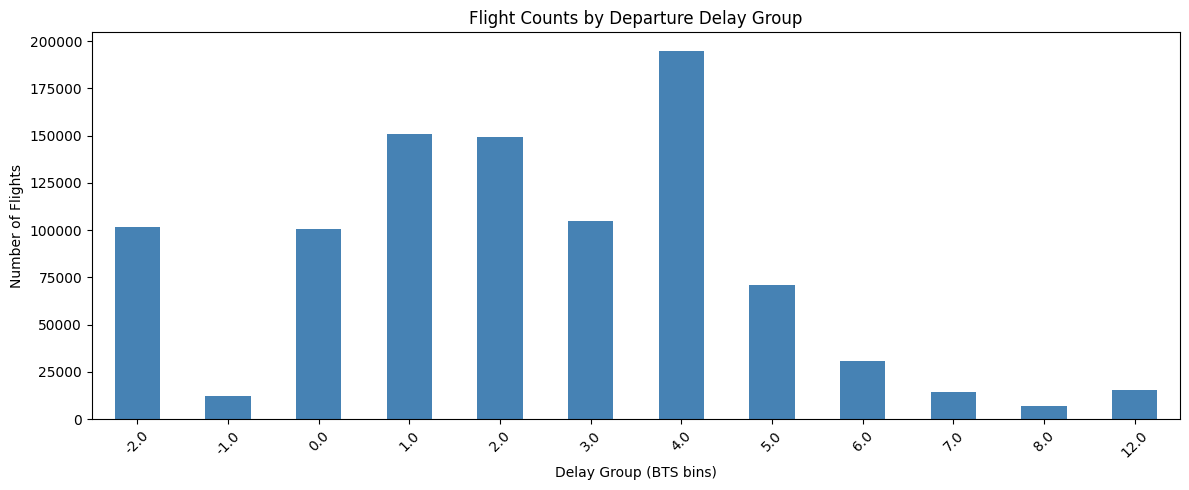

In [35]:
delay_group_counts = analyze_grouped_counts(df_cleaned)
print("Flight counts by DEP_DELAY_GROUP:")
print(delay_group_counts)

plt.figure(figsize=(12, 5))
delay_group_counts.plot(kind='bar', color='steelblue')
plt.title('Flight Counts by Departure Delay Group')
plt.xlabel('Delay Group (BTS bins)')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('flight_counts_by_delay_group.png', dpi=150)
plt.show()

---
## Section 7 — Delay Factor Distribution

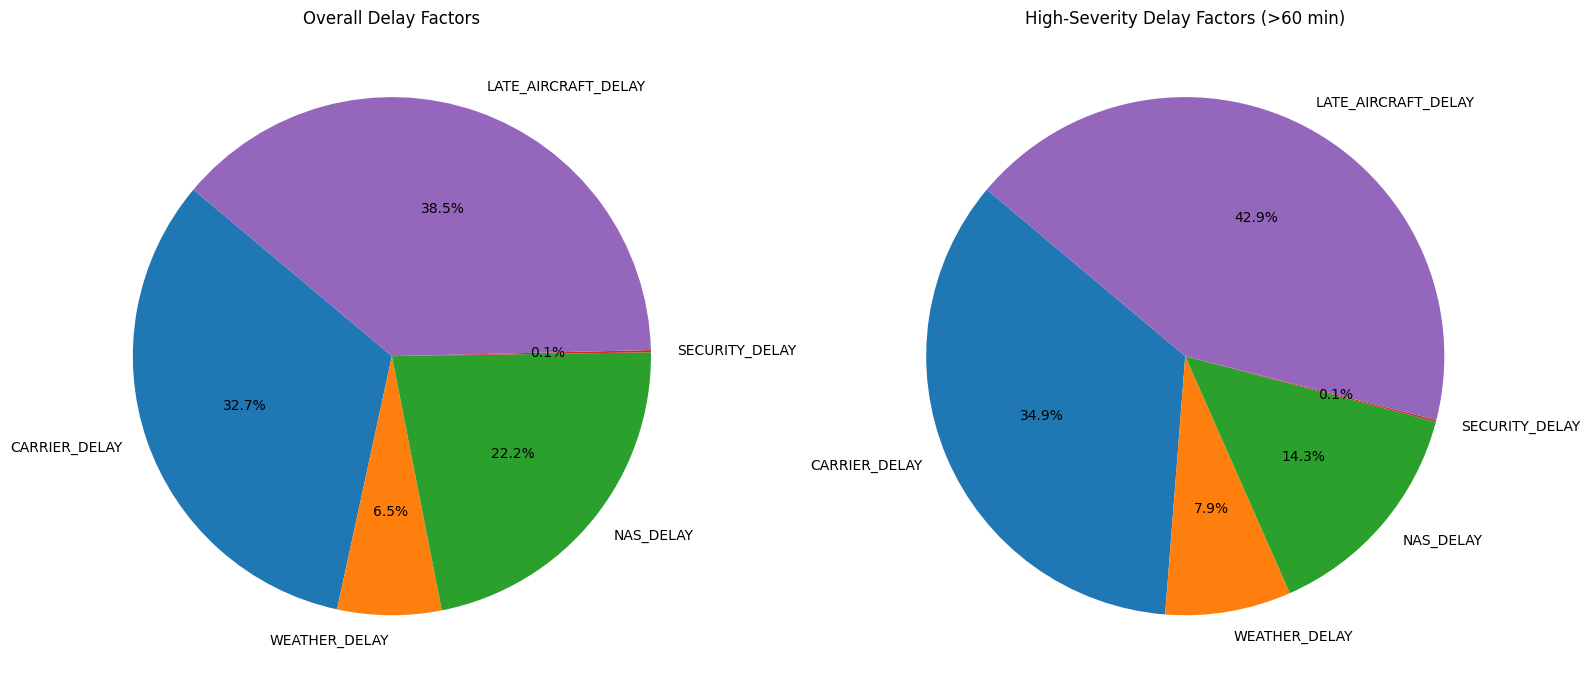

In [36]:
delay_factor_pie_charts(df_cleaned, DELAY_COLUMNS)

---
## Section 8 — Short-Haul vs Long-Haul Comparison

Short-haul (≤500 mi) avg delays:
 CARRIER_DELAY          24.301431
WEATHER_DELAY           6.236462
NAS_DELAY              14.584357
SECURITY_DELAY          0.077178
LATE_AIRCRAFT_DELAY    28.477538
dtype: float64

Long-haul (>1500 mi) avg delays:
 CARRIER_DELAY          25.072807
WEATHER_DELAY           2.665306
NAS_DELAY              16.641441
SECURITY_DELAY          0.128792
LATE_AIRCRAFT_DELAY    23.221169
dtype: float64


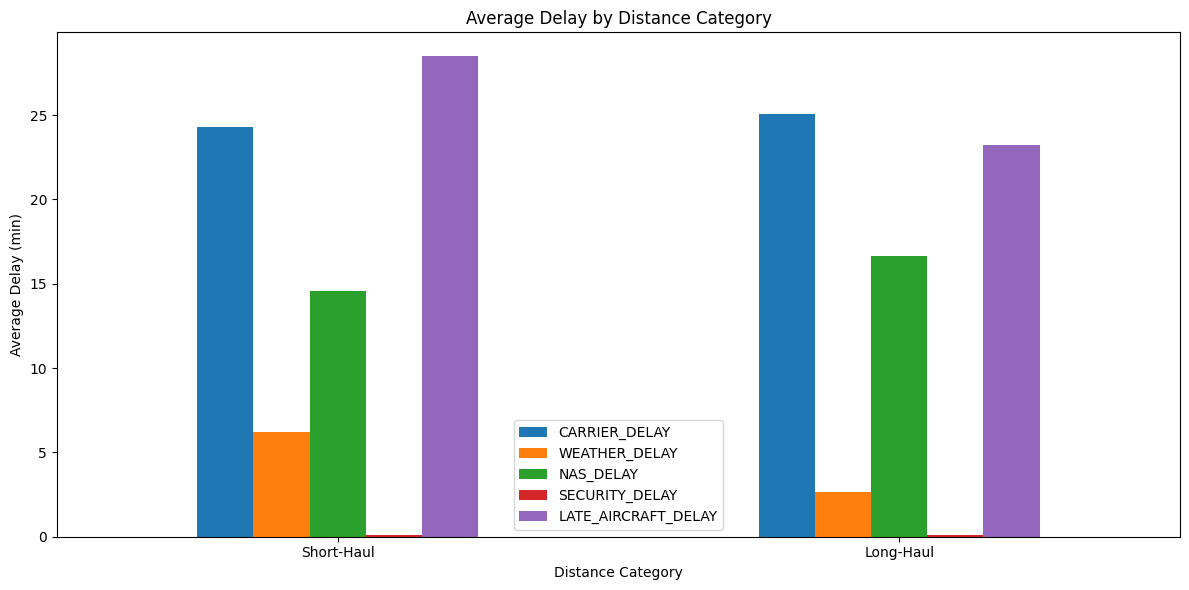

In [37]:
short_avg, long_avg = compare_short_long_haul(df_cleaned, DELAY_COLUMNS)
print("Short-haul (≤500 mi) avg delays:\n", short_avg)
print("\nLong-haul (>1500 mi) avg delays:\n", long_avg)

comparison_df = pd.DataFrame({'Short-Haul': short_avg, 'Long-Haul': long_avg}).T
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Average Delay by Distance Category')
plt.ylabel('Average Delay (min)')
plt.xlabel('Distance Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('short_vs_long_haul_delays.png', dpi=150)
plt.show()

---
## Section 9 — Top Cities by Delay Reason

In [38]:
top_cities_df = top_cities_by_delay(df_cleaned, DELAY_COLUMNS)
print("Top origin city for each delay reason:")
top_cities_df

Top origin city for each delay reason:


,City,Total Delay (min)
CARRIER_DELAY,"Chicago, IL",1329996.0
WEATHER_DELAY,"Chicago, IL",435712.0
NAS_DELAY,"Chicago, IL",1005623.0
SECURITY_DELAY,"Atlanta, GA",5254.0
LATE_AIRCRAFT_DELAY,"Chicago, IL",1793164.0


---
## Section 10 — Weather Delay in Dallas by Quarter

QUARTER
1    124943.0
2     97630.0
3    105402.0
4     51631.0
Name: WEATHER_DELAY, dtype: float64


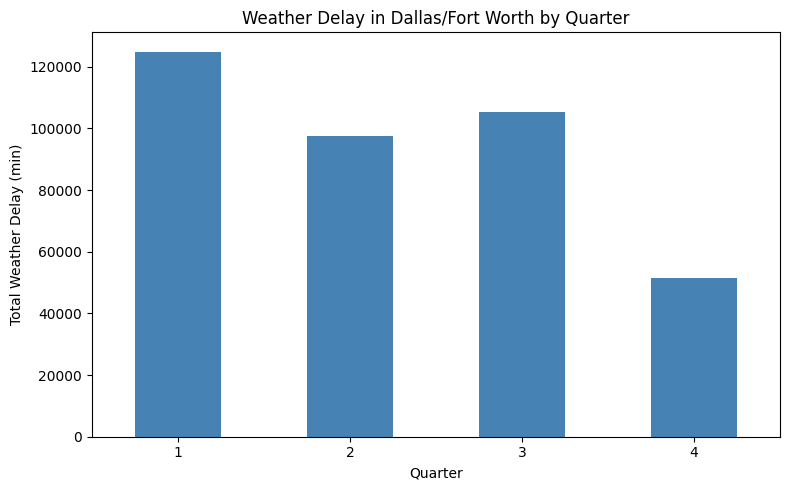

In [39]:
dallas_weather = analyze_weather_delay_in_dallas_by_quarter(df_cleaned)
if dallas_weather is not None:
    print(dallas_weather)
    plt.figure(figsize=(8, 5))
    dallas_weather.plot(kind='bar', color='steelblue')
    plt.title('Weather Delay in Dallas/Fort Worth by Quarter')
    plt.xlabel('Quarter')
    plt.ylabel('Total Weather Delay (min)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('dallas_weather_delay_by_quarter.png', dpi=150)
    plt.show()

---
## Section 11 — Airline Performance Metrics

In [40]:
airline_performance_df = calculate_airline_delay_metrics(df_cleaned)
airline_performance_df

,OP_UNIQUE_CARRIER,DEP_DEL15,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DEP_DELAY_NEW,Total_Flights,Delay_Ratio (%),Avg_Delay_Per_Flight (min),Total_Delay (min),Delay_Contribution (%)
0,AA,0.794972,4075654.0,708697.0,1945295.0,16900.0,5390735.0,77.330412,148814,79.497225,77.330412,12137281.0,17.627348
1,AS,0.693019,479720.0,67859.0,515355.0,7980.0,679251.0,43.915345,34481,69.301934,43.915345,1750165.0,2.541819
2,B6,0.789783,797994.0,79052.0,793063.0,4782.0,1255223.0,69.807040,39288,78.978314,69.807040,2930114.0,4.255495
3,DL,0.781283,3905679.0,474780.0,1944398.0,5923.0,2763889.0,68.556765,124988,78.128300,68.556765,9094669.0,13.208469
4,F9,0.798555,776895.0,79582.0,553778.0,0.0,1432549.0,78.786625,34198,79.855547,78.786625,2842804.0,4.128692
5,G4,0.818159,492172.0,210784.0,325993.0,4645.0,659525.0,80.760810,19495,81.815850,80.760810,1693119.0,2.458969
6,HA,0.721085,281938.0,19848.0,4881.0,1675.0,162147.0,49.311221,8698,72.108531,49.311221,470489.0,0.683306
7,MQ,0.727256,490823.0,303376.0,588287.0,2892.0,1025803.0,55.433247,37152,72.725560,55.433247,2411181.0,3.501833
8,NK,0.815821,489943.0,54685.0,921468.0,5741.0,502953.0,71.387250,26572,81.582117,71.387250,1974790.0,2.868048
9,OH,0.815714,1105711.0,259205.0,508248.0,6363.0,1973197.0,85.653189,42738,81.571435,85.653189,3852724.0,5.595430


In [41]:
best_airlines, worst_airlines = best_and_worst_airlines(airline_performance_df)

print("Top 5 Best Airlines (lowest delay ratio):")
print(best_airlines[['OP_UNIQUE_CARRIER', 'Delay_Ratio (%)', 'Avg_Delay_Per_Flight (min)']].to_string(index=False))

print("\nTop 5 Worst Airlines (highest delay ratio):")
print(worst_airlines[['OP_UNIQUE_CARRIER', 'Delay_Ratio (%)', 'Avg_Delay_Per_Flight (min)']].to_string(index=False))

Top 5 Best Airlines (lowest delay ratio):
OP_UNIQUE_CARRIER  Delay_Ratio (%)  Avg_Delay_Per_Flight (min)
               AS        69.301934                   43.915345
               YX        71.262272                   59.255442
               UA        71.988444                   64.046585
               HA        72.108531                   49.311221
               MQ        72.725560                   55.433247

Top 5 Worst Airlines (highest delay ratio):
OP_UNIQUE_CARRIER  Delay_Ratio (%)  Avg_Delay_Per_Flight (min)
               WN        85.594720                   55.495250
               G4        81.815850                   80.760810
               NK        81.582117                   71.387250
               OH        81.571435                   85.653189
               F9        79.855547                   78.786625


In [42]:
best_factors, worst_factors = airline_performance_by_factor(best_airlines, worst_airlines, DELAY_COLUMNS)

with pd.option_context('display.max_columns', None, 'display.expand_frame_repr', False):
    print("Best 5 Airlines — Delay Factor Breakdown:")
    print(best_factors.to_string(index=False))
    print("\nWorst 5 Airlines — Delay Factor Breakdown:")
    print(worst_factors.to_string(index=False))

Best 5 Airlines — Delay Factor Breakdown:
OP_UNIQUE_CARRIER  CARRIER_DELAY  WEATHER_DELAY  NAS_DELAY  SECURITY_DELAY  LATE_AIRCRAFT_DELAY
               AS       479720.0        67859.0   515355.0          7980.0             679251.0
               YX       738242.0       173889.0  1099738.0          2502.0            1178073.0
               UA      1951304.0       346019.0  2441014.0           359.0            2699016.0
               HA       281938.0        19848.0     4881.0          1675.0             162147.0
               MQ       490823.0       303376.0   588287.0          2892.0            1025803.0

Worst 5 Airlines — Delay Factor Breakdown:
OP_UNIQUE_CARRIER  CARRIER_DELAY  WEATHER_DELAY  NAS_DELAY  SECURITY_DELAY  LATE_AIRCRAFT_DELAY
               WN      2575120.0       268780.0  1975304.0         24671.0            4902923.0
               G4       492172.0       210784.0   325993.0          4645.0             659525.0
               NK       489943.0        54685.0   

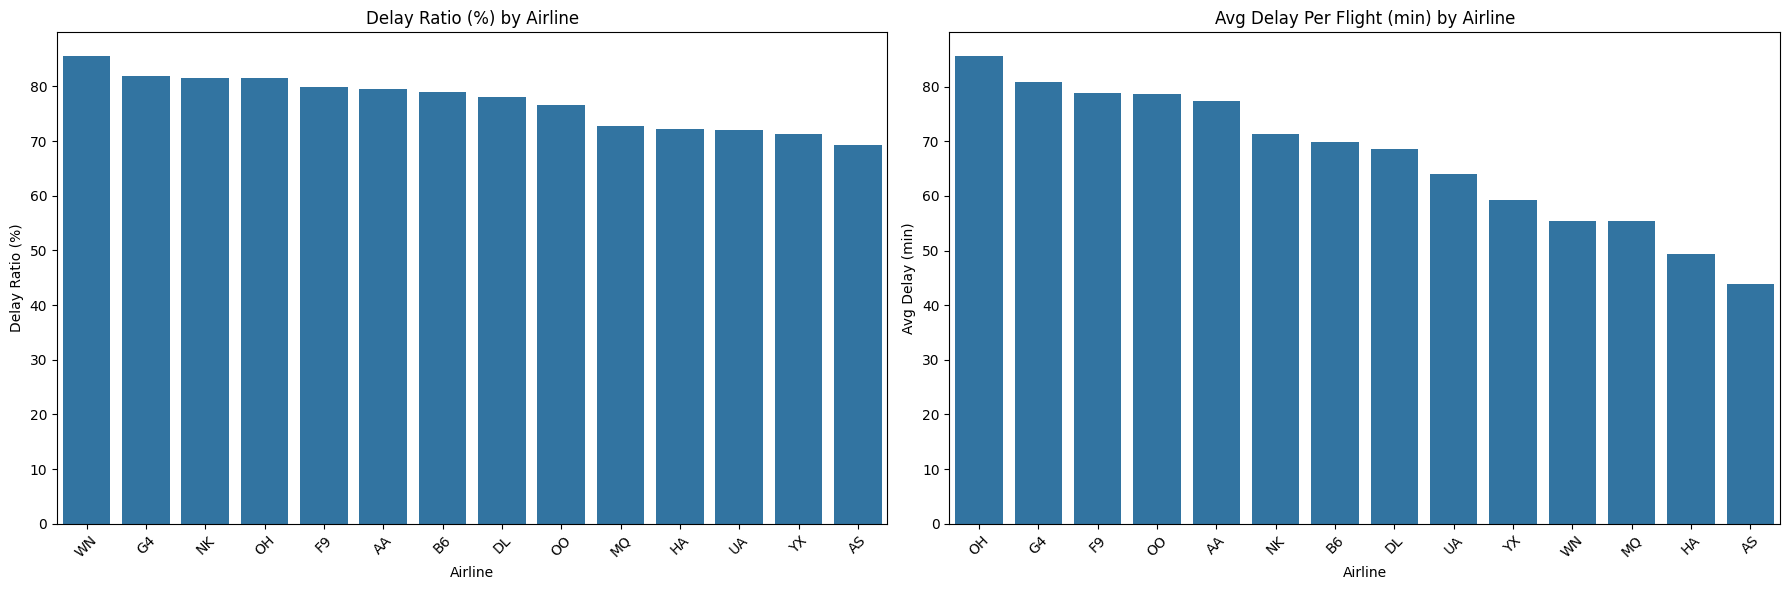

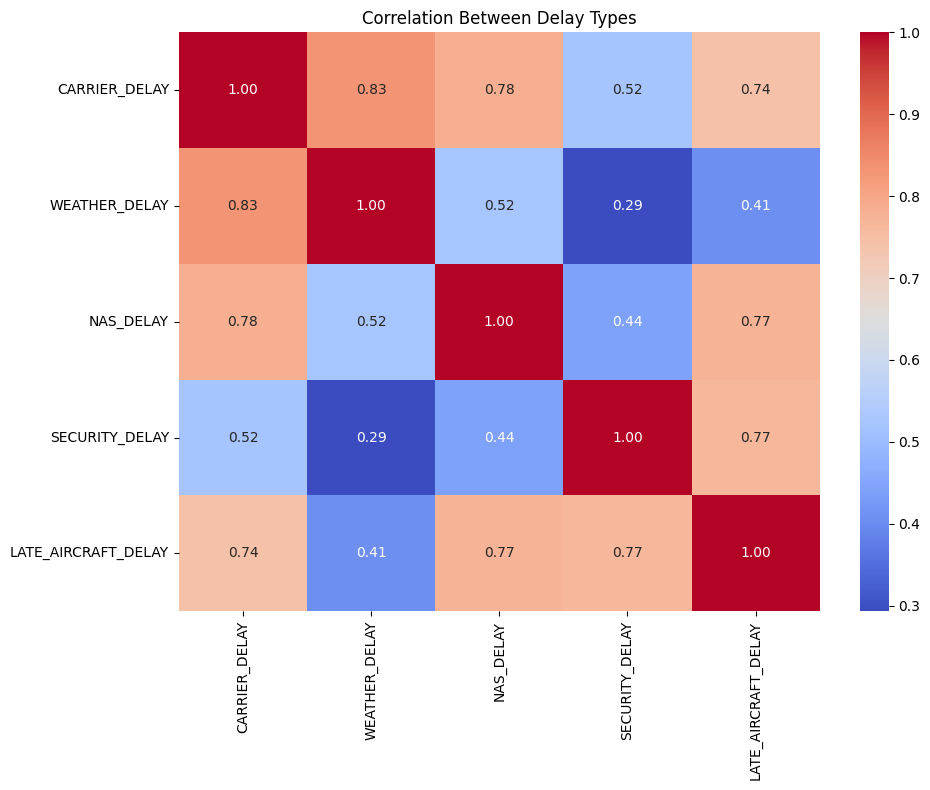

In [43]:
visualize_airline_performance_metrics(airline_performance_df)

In [44]:
airline_performance_df.to_csv('airline_performance_metrics.csv', index=False)
print("Saved: airline_performance_metrics.csv")

Saved: airline_performance_metrics.csv


---
## Section 12 — Classification Model (Random Forest)
**Task:** Predict whether a flight will be delayed ≥15 minutes (`DEP_DEL15`).  
**Baseline:** Logistic Regression | **Main model:** Random Forest  
**Features:** 5 delay-cause variables (carrier, weather, NAS, security, late aircraft)  
**Split:** 80% train / 20% test

Sampling 200,000 rows from 952,366 total rows.

=== Baseline: Logistic Regression ===


/Users/linwu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/linwu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/linwu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/linwu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/linwu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_s

              precision    recall  f1-score   support

           0       0.68      0.93      0.78      8608
           1       0.98      0.88      0.93     31392

    accuracy                           0.89     40000
   macro avg       0.83      0.90      0.85     40000
weighted avg       0.91      0.89      0.90     40000

Accuracy : 0.8894
Precision: 0.9786
Recall   : 0.8783
F1       : 0.9258

=== Main Model: Random Forest ===
              precision    recall  f1-score   support

           0       0.96      0.14      0.25      8608
           1       0.81      1.00      0.89     31392

    accuracy                           0.81     40000
   macro avg       0.88      0.57      0.57     40000
weighted avg       0.84      0.81      0.75     40000

Accuracy : 0.8140
Precision: 0.8093
Recall   : 0.9982
F1       : 0.8939


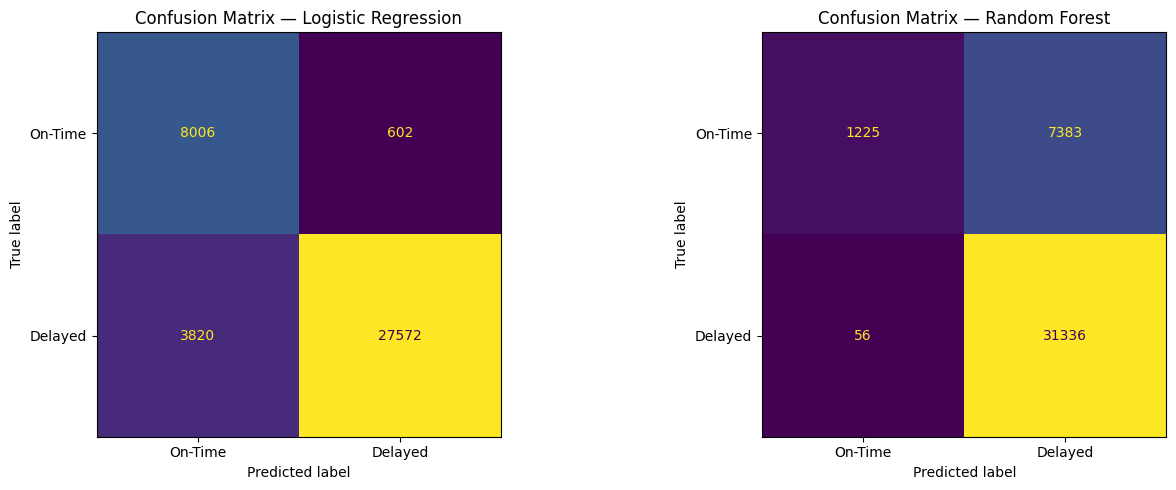


Average Delay Likelihood by Airline (Random Forest):
  — Best 5 airlines —
    AS: 71.69%
    YX: 73.59%
    UA: 73.13%
    HA: 79.02%
    MQ: 75.53%
  — Worst 5 airlines —
    WN: 83.56%
    G4: 79.84%
    NK: 74.41%
    OH: 81.54%
    F9: 79.46%

Saved: classification_metrics.json


In [45]:
rfc_model = train_and_evaluate_classifier(df_cleaned, best_airlines, worst_airlines)

---
## Section 13 — Regression Model (Linear Regression)
**Task:** Predict delay duration in minutes (`DEP_DELAY_NEW`).  
**Metric:** RMSE and R²


=== Regression: Random Forest Regressor (delayed flights only) ===
Sampling 200,000 rows from 838,657 total rows.
RMSE                : 14.84 minutes
Mean actual delay   : 76.54 minutes
Mean predicted delay: 76.46 minutes


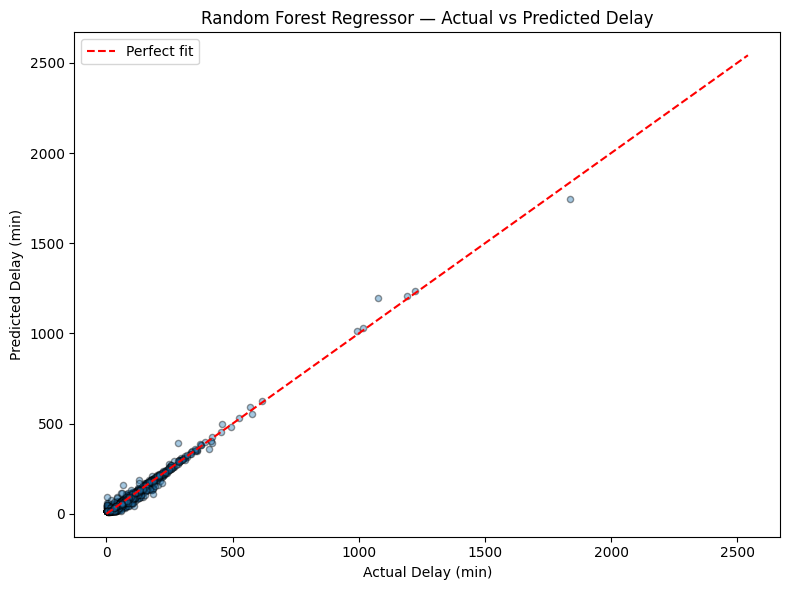

Saved: regression_metrics.json


In [46]:
rf_reg_model = random_forest_regression_analysis(df_cleaned)

---
## Section 14 — Streamlit App

The cell below contains the **complete Streamlit application code**.  
Run the next cell to write `app.py`, then follow the instructions to launch it.

### How to run

#### Option A — Google Colab (using ngrok)
```bash
# 1. Install dependencies
!pip install streamlit pyngrok -q

# 2. Write the app file (run the cell below)

# 3. Start Streamlit in the background and expose via ngrok
!streamlit run app.py &
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("Streamlit URL:", public_url)
```

#### Option B — Local machine
```bash
pip install streamlit scikit-learn pandas matplotlib seaborn
streamlit run app.py
# Opens automatically at http://localhost:8501
```

### Input fields
| Field | Type |
|---|---|
| Departure Airport | Dropdown |
| Arrival Airport | Dropdown |
| Travel Month | Dropdown |
| Airline | Dropdown |

### Outputs
- Recommended airline (lowest predicted delay risk)
- Delay probability for each airline (classification)
- Expected delay duration in minutes (regression)
- Bar chart comparison across airlines
- Delay cause breakdown (donut chart)

In [47]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Flight Delay Predictor",
    page_icon="✈️",
    layout="wide"
)

DELAY_COLS = ["CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY",
              "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY"]
DELAY_LABELS = ["Carrier", "Weather", "NAS", "Security", "Late Aircraft"]

# ── Data loading (cached) ─────────────────────────────────────────────────────
@st.cache_data
def load_data(directory="Dataset"):
    files = glob.glob(f"{directory}/*.csv")
    if not files:
        st.error(f"No CSV files found in '{directory}'.")
        st.stop()
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    clean_cols = ["DEP_DELAY", "DEP_DELAY_NEW", "DEP_DEL15"] + DELAY_COLS
    df = df.dropna(subset=clean_cols).copy()
    for c in DELAY_COLS:
        df[c] = df[c].clip(lower=0)
    return df

# ── Model training (cached) ───────────────────────────────────────────────────
@st.cache_resource
def train_models(df):
    X = df[DELAY_COLS].fillna(0)
    y_cls = df["DEP_DEL15"].astype(int)
    y_reg = df["DEP_DELAY_NEW"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_cls, test_size=0.2, random_state=42)
    rfc = RandomForestClassifier(n_estimators=100, max_depth=10,
                                  random_state=42, n_jobs=-1)
    rfc.fit(X_tr, y_tr)
    lr = LinearRegression().fit(X, y_reg)
    return rfc, lr

# ── Airline metrics (cached) ──────────────────────────────────────────────────
@st.cache_data
def compute_airline_metrics(df):
    perf = df.groupby("OP_UNIQUE_CARRIER").agg(
        Delay_Ratio        = ("DEP_DEL15",     "mean"),
        Avg_Delay          = ("DEP_DELAY_NEW", "mean"),
        CARRIER_DELAY      = ("CARRIER_DELAY",      "mean"),
        WEATHER_DELAY      = ("WEATHER_DELAY",      "mean"),
        NAS_DELAY          = ("NAS_DELAY",          "mean"),
        SECURITY_DELAY     = ("SECURITY_DELAY",     "mean"),
        LATE_AIRCRAFT_DELAY= ("LATE_AIRCRAFT_DELAY","mean"),
    ).reset_index()
    perf["Delay_Ratio (%)"] = perf["Delay_Ratio"] * 100
    perf["Reliability"] = perf["Delay_Ratio (%)"].apply(
        lambda x: "⭐⭐⭐ Excellent" if x < 20
                  else ("⭐⭐ Good" if x < 30 else "⭐ Poor")
    )
    return perf

# ── Load everything ───────────────────────────────────────────────────────────
df = load_data()
rfc, lr_model = train_models(df)
airline_metrics = compute_airline_metrics(df)

# ── Sidebar ───────────────────────────────────────────────────────────────────
st.sidebar.image("https://upload.wikimedia.org/wikipedia/commons/thumb/3/3b/Airplane_silhouette.svg/120px-Airplane_silhouette.svg.png", width=80)
st.sidebar.title("✈️ Flight Delay Predictor")
st.sidebar.markdown("Powered by **Random Forest** + **Linear Regression**")
st.sidebar.markdown("---")

origin_cities  = sorted(df["ORIGIN_CITY_NAME"].dropna().unique())
dest_cities    = sorted(df["DEST_CITY_NAME"].dropna().unique())
airlines       = sorted(df["OP_UNIQUE_CARRIER"].dropna().unique())
months         = list(range(1, 13))
month_names    = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"]

origin  = st.sidebar.selectbox("Departure City", origin_cities)
dest    = st.sidebar.selectbox("Arrival City",   dest_cities)
month   = st.sidebar.selectbox("Travel Month",   months,
                                format_func=lambda m: month_names[m-1])
predict_btn = st.sidebar.button("🔍 Predict & Compare", use_container_width=True)

# ── Main page ─────────────────────────────────────────────────────────────────
st.title("✈️ U.S. Flight Delay Prediction & Airline Recommendation")
st.markdown(
    "Enter your trip details on the left, then click **Predict & Compare** "
    "to get real-time delay predictions and airline recommendations."
)

if predict_btn:
    # Filter historical data for the chosen route + month
    route_df = df[
        (df["ORIGIN_CITY_NAME"] == origin) &
        (df["DEST_CITY_NAME"]   == dest)   &
        (df["MONTH"]            == month)
    ]

    if route_df.empty:
        st.warning(
            "No historical data found for this route/month combination. "
            "Showing predictions based on overall airline averages."
        )
        route_df = df[df["MONTH"] == month]

    results = []
    for carrier in airlines:
        carrier_df = route_df[route_df["OP_UNIQUE_CARRIER"] == carrier]
        if carrier_df.empty:
            carrier_df = df[df["OP_UNIQUE_CARRIER"] == carrier]
        if carrier_df.empty:
            continue
        X_pred = carrier_df[DELAY_COLS].fillna(0)
        delay_prob    = rfc.predict_proba(X_pred)[:, 1].mean()
        expected_delay = lr_model.predict(X_pred).mean()
        avg_causes    = X_pred.mean().tolist()
        results.append({
            "Airline": carrier,
            "Delay Probability (%)": round(delay_prob * 100, 1),
            "Expected Delay (min)": round(max(expected_delay, 0), 1),
            **{label: round(val, 1) for label, val in zip(DELAY_LABELS, avg_causes)}
        })

    if not results:
        st.error("Could not generate predictions. Please try a different route.")
        st.stop()

    results_df = pd.DataFrame(results).sort_values("Delay Probability (%)", ascending=True)

    # ── Best airline recommendation ───────────────────────────────────────────
    best = results_df.iloc[0]
    st.markdown("---")
    st.subheader("🏆 Recommended Airline")
    col1, col2, col3 = st.columns(3)
    col1.metric("Airline",                best["Airline"])
    col2.metric("Delay Probability",      f"{best['Delay Probability (%)']:.1f}%")
    col3.metric("Expected Delay",         f"{best['Expected Delay (min)']:.1f} min")

    # ── Airline comparison table ──────────────────────────────────────────────
    st.markdown("---")
    st.subheader("📊 Airline Comparison")
    display_df = results_df[["Airline", "Delay Probability (%)", "Expected Delay (min)"]].copy()
    display_df = display_df.merge(
        airline_metrics[["OP_UNIQUE_CARRIER", "Reliability"]],
        left_on="Airline", right_on="OP_UNIQUE_CARRIER", how="left"
    ).drop(columns="OP_UNIQUE_CARRIER")
    st.dataframe(display_df.reset_index(drop=True), use_container_width=True)

    # ── Bar chart comparison ───────────────────────────────────────────────────
    st.markdown("---")
    st.subheader("📈 Delay Probability & Expected Duration by Airline")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    colors = ["#2ecc71" if a == best["Airline"] else "#3498db"
              for a in results_df["Airline"]]
    ax1.barh(results_df["Airline"], results_df["Delay Probability (%)"], color=colors)
    ax1.set_xlabel("Delay Probability (%)")
    ax1.set_title("Delay Probability by Airline")
    ax1.axvline(x=results_df["Delay Probability (%)"].mean(), color="red",
                linestyle="--", label="Average")
    ax1.legend()

    ax2.barh(results_df["Airline"], results_df["Expected Delay (min)"], color=colors)
    ax2.set_xlabel("Expected Delay (min)")
    ax2.set_title("Expected Delay Duration by Airline")

    green_patch = mpatches.Patch(color="#2ecc71", label="Recommended")
    blue_patch  = mpatches.Patch(color="#3498db", label="Other")
    fig.legend(handles=[green_patch, blue_patch], loc="lower center", ncol=2)
    plt.tight_layout()
    st.pyplot(fig)

    # ── Delay cause donut chart ────────────────────────────────────────────────
    st.markdown("---")
    st.subheader(f"🍩 Delay Cause Breakdown — {best['Airline']}")
    cause_vals = [best.get(label, 0) for label in DELAY_LABELS]
    cause_vals = [max(v, 0.01) for v in cause_vals]  # avoid zero-wedge rendering

    fig2, ax = plt.subplots(figsize=(7, 7))
    wedges, texts, autotexts = ax.pie(
        cause_vals, labels=DELAY_LABELS,
        autopct="%1.1f%%", startangle=90,
        pctdistance=0.8,
        wedgeprops=dict(width=0.5)
    )
    ax.set_title(f"Avg Delay Cause — {best['Airline']} ({month_names[month-1]})")
    st.pyplot(fig2)

else:
    st.info("👈 Fill in your trip details in the sidebar and click **Predict & Compare**.")
    st.markdown("### 📌 Overall Airline Delay Statistics")
    st.dataframe(
        airline_metrics[["OP_UNIQUE_CARRIER", "Delay_Ratio (%)",
                         "Avg_Delay", "Reliability"]]
        .rename(columns={"OP_UNIQUE_CARRIER": "Airline",
                         "Avg_Delay": "Avg Delay (min)"})
        .sort_values("Delay_Ratio (%)"),
        use_container_width=True
    )
'''

with open('app.py', 'w') as f:
    f.write(app_code.strip())

print("app.py written successfully!")

app.py written successfully!


---
## Section 15 — Launch Streamlit (Colab)
Run the cell below **only in Google Colab** to start the app and get a public URL.

In [49]:
import subprocess, sys, time

# Install Streamlit if needed
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'streamlit', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', '-q'],
    check=True
)

# Kill any existing Streamlit process
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(1)

# Launch Streamlit
subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'app.py', '--server.port=8501']
)
time.sleep(4)

print('Streamlit is running!')
print('Open your browser at:  http://localhost:8501')
print("To stop: run 'pkill -f streamlit' in terminal")

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.



      👋 Welcome to Streamlit!

      If you'd like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  Streamlit is running!
Open your browser at:  http://localhost:8501
To stop: run 'pkill -f streamlit' in terminal
